![Redis](https://redis.io/wp-content/uploads/2024/04/Logotype.svg?auto=webp&quality=85,75&width=120)

# Understanding the Semantic Router
When we use the semantic router as a classification engine, there are some concepts that we can draw in parallel to traditional classification tasks:
- In the same way that data should be (linearly or non-linearly) separable when performing classification, each route in the semantic router should be semantically distinct to prevent ambiguous routing. 
- To achieve this, the quality of data usually matters more than the quantity of data.

That being said, a semantic router is **NOT** a traditional classifier, since separability is expressed in terms of distance in embedding space, rather than explicit boundaries. Furthermore, building a semantic router does not involve any training step (as in machine learning). Regardless, the intuition and approach are similar - to ensure your semantic route is accurate, each route should occupy a distinct and well-separated region in embedding space, even if no explicit decision boundary is learned.

To understand this concept a little better, we can turn to a few visualizations and metrics. 

## Before we get started
To understand more about the concepts discussed in this notebook, be sure to check out the following:
- [Basic Semantic Routing](00_semantic_routing.ipynb) - A notebook demonstrating how to use a semantic router from RedisVL
- [Advanced Semantic Routing](02_advanced_semantic_routing.ipynb) - A notebook discussing ways to improve the routing performance of your semantic router


## Let's Begin!
<a href="https://colab.research.google.com/github/redis-developer/redis-ai-resources/blob/main/python-recipes/semantic-router/03_router_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

First, let's download the required packages.

In [72]:
%pip install -q "redisvl[sentence-transformers]>=0.6.0" datasets scikit-learn matplotlib 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Install Redis 

#### For Colab
Use the shell script below to download, extract, and install Redis Stack directly from the Redis package archive.

In [ ]:
# NBVAL_SKIP
# Colab only: install and start Redis Stack.
%%sh
sudo apt-get install -y -qq lsb-release curl gpg > /dev/null
curl -fsSL https://packages.redis.io/gpg | sudo gpg --dearmor -o /usr/share/keyrings/redis-archive-keyring.gpg
sudo chmod 644 /usr/share/keyrings/redis-archive-keyring.gpg
echo "deb [signed-by=/usr/share/keyrings/redis-archive-keyring.gpg] https://packages.redis.io/deb $(lsb_release -cs) main" | sudo tee /etc/apt/sources.list.d/redis.list
sudo apt-get update -qq > /dev/null
sudo apt-get install -y -qq redis > /dev/null

redis-server --version
redis-server --daemonize yes --loadmodule /usr/lib/redis/modules/redisearch.so

#### For Alternative Environments
There are many ways to get the necessary redis-stack instance running.
1. On cloud, deploy a [FREE instance of Redis in the cloud](https://redis.com/try-free/). Or, if you have your
own version of Redis Enterprise running, that works too!
2. Per OS, [see the docs](https://redis.io/docs/latest/operate/oss_and_stack/install/install-stack/)
3. With docker: `docker run -d --name redis-stack-server -p 6379:6379 redis/redis-stack-server:latest`

### Define the Redis Connection URL

By default this notebook connects to the local instance of Redis Stack. **If you have your own Redis Enterprise instance** - replace REDIS_PASSWORD, REDIS_HOST and REDIS_PORT values with your own.

In [73]:
import os
from redis import Redis

# Replace values below with your own if using Redis Cloud instance
REDIS_HOST = os.getenv("REDIS_HOST", "localhost") # ex: "redis-18374.c253.us-central1-1.gce.cloud.redislabs.com"
REDIS_PORT = os.getenv("REDIS_PORT", "6379")      # ex: 18374
REDIS_PASSWORD = os.getenv("REDIS_PASSWORD", "")  # ex: "1TNxTEdYRDgIDKM2gDfasupCADXXXX"

# If SSL is enabled on the endpoint, use rediss:// as the URL prefix
REDIS_URL = f"redis://:{REDIS_PASSWORD}@{REDIS_HOST}:{REDIS_PORT}"

client = Redis.from_url(REDIS_URL)
client.ping()
client.flushall()

True

## Imports

In [74]:
import random
from collections import defaultdict
from pprint import pprint, pformat
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from redisvl.extensions.router import Route, SemanticRouter
from redisvl.utils.vectorize import HFTextVectorizer

random.seed(123)

## Data setup

This notebook follows the same data setup as the [Advanced Semantic Routing](02_advanced_semantic_routing.ipynb) notebook. We use a subset of identified routes from the [CLINC dataset](https://huggingface.co/datasets/DeepPavlov/clinc150) to perform intent classification. From there, we visualize the semantic neighbourhood of each route.

In [75]:
from datasets import load_dataset
data = load_dataset("clinc_oos", "plus")

In [76]:
intents = [
    "balance",
    "transactions",
    "transfer",
    "pay_bill",
    "bill_due",
    "card_declined",
    "report_fraud",
    "freeze_account",
    "credit_score",
    "direct_deposit",
]

In [77]:
# Create a subset of data only with the intents we are interested in
intent_names = data['train'].features['intent'].names
intent_ids = [intent_names.index(intent) for intent in intents]

data_subset = data.filter(lambda example: example['intent'] in intent_ids)

# View a sample of the data subset
{
    split: {
        'rows': len(data_subset[split]),
        'sample_texts': data_subset[split]['text'][:3],
        'sample_intents': [intent_names[i] for i in data_subset[split]['intent'][:3]],
    }
    for split in data_subset
}

{'train': {'rows': 1000,
  'sample_texts': ['i need $20000 transferred from my savings to my checking',
   'complete a transaction from savings to checking of $20000',
   'transfer $20000 from my savings account to checking account'],
  'sample_intents': ['transfer', 'transfer', 'transfer']},
 'validation': {'rows': 200,
  'sample_texts': ['transfer ten dollars from my wells fargo account to my bank of america account',
   'take one hundred and fifty bucks from my wells fargo checking account and put it in my wells fargo savings account',
   'put one hundred and seventy five bucks in my wells fargo checking account from my citibank savings account'],
  'sample_intents': ['transfer', 'transfer', 'transfer']},
 'test': {'rows': 300,
  'sample_texts': ['can you please provide me with assistance in moving money from one account to another',
   'i would like help moving money between accounts',
   'can you assist me in moving money from one account to another'],
  'sample_intents': ['transf

In [78]:
# Group the dataset by intent classes
train_by_intent = defaultdict(list)

for example in data_subset['train']:
    intent_name = intent_names[example['intent']]
    train_by_intent[intent_name].append(example['text'])

train_by_intent = dict(train_by_intent)
pprint(train_by_intent)

{'balance': ['savings account balance at chase bank please',
             'check chase bank for my checking balance',
             'what is my checking account balance at chase',
             'i want my checking balance at chase',
             "what's my savings balance at chase",
             'do i have enough money in my chime bank account to take ashley '
             'to the movies tuesday',
             'check my visa account and see if i have enough money for dinner '
             'tonight',
             'is tehre enough in my bluebird account for groceries this week',
             'do i have enough in my sears account to buy a new dishwasher',
             'is there enough money in my discover account for a new pair of '
             'jeans',
             'what is the total of my bank accounts',
             'what is in my bank accounts',
             'what is the balance on my bank accounts',
             'what is remaining in my bank acccounts',
             'how much money is

By grouping the dataset by intent classes, it is easier to visualize what each route and its respective references might look like.

## Creating our Semantic Routers

We will create two semantic routers, one using 'low-quality route references', and the other using 'high-quality route references'.

### Low quality references

Low-quality references are those that are poorly defined. They are more likely to be inconsistent, repetitive, noisy, and might contain overlap in meaning with other routes.

Here, we simulate one possible form of low-quality references using short, user-style examples. These references are often repetitive in meaning and do not provide enough coverage to capture the full meaning of their respective routes. In essence, they do not contain enough information and variation to clearly define the routes, so a semantic router built with these references would likely struggle to route accurately.

In [79]:
# Create low quality routes using low quality references
low_quality_references = {
    'balance': [
        'check my account',
        'how much do i have',
        'money in my account',
        'look at my balance please',
        'what is in my bank account',
        'show me my bank balance',
        'how much money is left',
        'what do i have available',
        'tell me how much money i have',
        'see what is in my account',
        'account balance please',
        'do i have money right now',
        'what is my amount',
        'check how much i have left',
        'current money in account',
        'how much is sitting in my account',
        'available funds in my account',
        'look up my balance',
        'can you check my money',
        'show the amount in my bank',
    ],
    'transactions': [
        'show me my account activity',
        'what happened in my account',
        'recent stuff on my card',
        'let me see my purchases',
        'check my account history',
        'show my recent transactions',
        'what did i spend money on',
        'i want to see account activity',
        'what charges do i have',
        'show me recent charges',
        'what went through on my card',
        'see my payment history',
        'show my bank activity',
        'what happened with my money',
        'transaction list please',
        'tell me my recent spending',
        'show me account movements',
        'i want to review my purchases',
        'what transactions do i have',
        'show me charges from yesterday',
    ],
    'transfer': [
        'move money for me',
        'send money to another account',
        'transfer some cash',
        'help me move funds',
        'put money somewhere else',
        'move my money to another bank',
        'can you transfer funds',
        'send some money',
        'move cash around',
        'i need to move money',
        'help me send money out',
        'make a bank transfer',
        'put funds into another account',
        'transfer money between accounts',
        'send funds for me',
        'move balance to a different place',
        'i want to shift some money',
        'move my money today',
        'send cash to another account',
        'transfer 50 dollars to savings',
    ],
    'pay_bill': [
        'pay something for me',
        'i need to pay my bill',
        'make a payment',
        'help me pay this',
        'pay my card bill',
        'pay my electric bill',
        'can you make this payment',
        'help me pay a charge',
        'i need to make a bill payment',
        'process my bill payment',
        'pay the amount i owe',
        'pay my phone bill',
        'make a bill payment for me',
        'help me pay this off',
        'pay my monthly bill',
        'can you pay this bill',
        'submit payment for my bill',
        'i want to pay something now',
        'make payment on my account',
        'pay my water bill today',
    ],
    'bill_due': [
        'when do i need to pay',
        'is my bill coming up',
        'when is payment due',
        'do i owe something soon',
        'tell me about my bill date',
        'when is my bill due',
        'what is the due date',
        'when do i have to make payment',
        'how soon do i need to pay',
        'when should i pay my bill',
        'is my payment due now',
        'what day is my bill due',
        'tell me my payment deadline',
        'when is the next due date',
        'am i late on my bill',
        'when do i owe this by',
        'bill deadline please',
        'when does this charge need payment',
        'how much time do i have to pay',
        'is my visa bill due this week',
    ],
    'card_declined': [
        'my card did not work',
        'why was my card rejected',
        'card problem at store',
        'my payment would not go through',
        'something is wrong with my card',
        'my card got declined',
        'why cant i use my card',
        'card not working today',
        'my card failed',
        'i cannot pay with my card',
        'my debit card is not working',
        'credit card did not go through',
        'payment was declined',
        'my card was denied',
        'why is my card failing',
        'card issue during payment',
        'i tried paying and it failed',
        'my card would not process',
        'why wont my card swipe',
        'my visa got declined at the store',
    ],
    'report_fraud': [
        'something weird happened in my account',
        'i do not recognize this charge',
        'there is a suspicious payment',
        'i think my account was used',
        'report something bad on my card',
        'this transaction is not mine',
        'someone used my card',
        'i see a fraudulent charge',
        'there is weird activity in my account',
        'i need to report fraud',
        'this payment looks fake',
        'i did not make this purchase',
        'there is suspicious activity',
        'report an unauthorized transaction',
        'i think someone charged my account',
        'my account has a bad transaction',
        'this charge is unfamiliar',
        'i want to flag this payment',
        'someone spent money from my account',
        'report a strange amazon charge',
    ],
    'freeze_account': [
        'lock my account',
        'freeze things for now',
        'stop my card or account',
        'secure my account right now',
        'block my bank account',
        'freeze my account please',
        'put a hold on my account',
        'lock down my card',
        'stop all activity on my account',
        'can you freeze everything',
        'disable my account for now',
        'temporarily lock my card',
        'shut down my account access',
        'i want to block my card',
        'freeze my banking access',
        'put my account on hold',
        'lock my banking account',
        'turn off my card for now',
        'stop usage on my account',
        'freeze my checking account immediately',
    ],
    'credit_score': [
        'check my credit',
        'what is my score',
        'show me my credit rating',
        'credit info please',
        'how is my credit looking',
        'what is my credit score',
        'can i see my credit score',
        'tell me my credit number',
        'check my credit rating',
        'i want my credit info',
        'show credit details',
        'how good is my credit',
        'credit score check',
        'what does my credit look like',
        'give me my score',
        'can you look at my credit',
        'show my current credit score',
        'i need my credit information',
        'what score do i have',
        'is my credit score above 700',
    ],
    'direct_deposit': [
        'set up paycheck stuff',
        'how do i deposit salary here',
        'direct deposit help',
        'send my pay to this account',
        'bank details for my paycheck',
        'how do i set up direct deposit',
        'i want my salary here',
        'put my paycheck in this account',
        'help with paycheck deposit',
        'where do i send payroll',
        'how can i get paid here',
        'set up salary deposit',
        'paycheck setup help',
        'i need payroll details',
        'how do i receive my salary here',
        'link my paycheck to this account',
        'direct deposit setup',
        'get my wages sent here',
        'what info do i need for payroll',
        'set up direct deposit for my employer',
    ],
}

# Create the routes to be used by the semantic router later
low_quality_routes = [
    Route(name=route_name, references=texts)
    for route_name, texts in low_quality_references.items()
]


### High quality references

On the other hand, high-quality references are those that are well-defined. They are more likely to be consistent, diverse, and clearly representative of their respective routes, with less overlap in meaning across routes.

Here, we use the subset we created earlier (from the CLINC dataset) as high-quality references. The dataset is carefully curated for intent classification and is likely to contain enough information and variation to capture what each route means more clearly. Hence, a semantic router built with these references would likely route more accurately.

To keep the comparison fair, we downsample the dataset to 20 samples per route.

In [80]:
# Downsample the curated CLINC examples so the comparison stays focused on
# reference quality rather than the number of examples per route.
num_samples_per_route = 20

high_quality_references = {
    route_name: random.sample(references, num_samples_per_route)
    for route_name, references in train_by_intent.items()
}

pprint(high_quality_references)

{'balance': ['could you check my bank balance for me',
             'do i have enough in my sears account to buy a new dishwasher',
             'savings account balance at chase bank please',
             'how much is left of mastercard',
             'is there enough money in my bank of hawaii for vacation',
             'do i have enough in my boa account for a new pair of skis',
             'what is remaining in my bank acccounts',
             'do i have enough money in my chime bank account to take ashley '
             'to the movies tuesday',
             'what is in my bank accounts',
             'please let me know what my current bank balance is',
             'what is the value of my bank accounts',
             'what is the balance of my bank accounts',
             'what is my checking account balance at chase',
             'how much is available in my savings account',
             'do i have any cash left',
             "what's my checking balance",
             'do 

In [81]:
high_quality_routes = [
    Route(name=route_name, references=texts)
    for route_name, texts in high_quality_references.items()
]

### Raw performance comparison

We compare the raw routing performance of semantic routers built using the low-quality references and high-quality references respectively, using classification accuracy on the test set from the CLINC dataset.

In [82]:
vectorizer = HFTextVectorizer()

low_quality_router = SemanticRouter(
    name='low-quality-router',
    routes=low_quality_routes,
    vectorizer=vectorizer,
    redis_client=client,
    overwrite=True,
)

high_quality_router = SemanticRouter(
    name='high-quality-router',
    routes=high_quality_routes,
    vectorizer=vectorizer,
    redis_client=client,
    overwrite=True,
)

In [83]:
# Helper function to measure classification accuracy of semantic router
def evaluate_router_accuracy(router, split="test"):
    """
    Measure the accuracy of a semantic router on a CLINC split.
    """
    eval_split = data_subset[split]
    num_correct = 0
    num_examples = len(eval_split)

    for example in eval_split:
        text = example["text"]
        true_intent = intent_names[example["intent"]]

        # Route the example through the semantic router and compare the
        # predicted route name against the ground-truth intent label.
        prediction = router(statement=text)
        predicted_intent = prediction.name

        if predicted_intent == true_intent:
            num_correct += 1

    # Return accuracy
    return num_correct / num_examples


In [84]:
low_quality_routing_accuracy = evaluate_router_accuracy(low_quality_router)
print(f"Accuracy of semantic router on low-quality references: {100 * low_quality_routing_accuracy:.2f}%")

high_quality_routing_accuracy = evaluate_router_accuracy(high_quality_router)
print(f"Accuracy of semantic router on high-quality references: {100 * high_quality_routing_accuracy:.2f}%")

Accuracy of semantic router on low-quality references: 89.67%
Accuracy of semantic router on high-quality references: 92.67%


As expected, the router built with high-quality references achieves higher test accuracy, suggesting that clearer and more representative references improve routing performance.

## Visualizing (and measuring) Route Quality

Now that we have confirmed the performance difference, we can look at how the route references are arranged in embedding space.

To visualize the semantic neighbourhood of each route, we can use PCA (Principal Component Analysis, see more [here](https://scikit-learn.org/stable/modules/decomposition.html)) to reduce the dimensionality of the embedding vectors into a space that is easily visualized. PCA projects high-dimensional embeddings into lower dimensions (we choose 2D for visualization) while preserving as much overall variance as possible. 

In our examples, we can use PCA to visualize how the embedding model represents the route references. If examples from the same intent cluster together, that suggests the embedding model represents them similarly, and hence they are semantically similar. Conversely, if two intent clusters overlap, that suggests the intents may be semantically hard to separate. A well-defined semantic neighbourhood would have clearly separable clusters, while poorly defined routes (using low-quality route references) would have overlaps between semantic neighbourhoods.

Additionally, we use [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) to measure how well each example fits within its own cluster, compared with the nearest neighbouring cluster. Here, it measures cluster separation in the original embedding space (rather than the 2D reduced PCA space). Nevertheless, it gives us a good numerical measure of cluster separation, in addition to the actual 2D plots.

NOTE: <b>PCA is used here only as a visualization tool</b>, so clear clusters in PCA-reduced space do not necessarily translate to clear clusters in actual semantic space. After all, PCA finds directions of maximum variance in the original embedding space, then projects the data into a lower-dimensional subspace. Distances in PCA-reduced space are projected distances, so they should be treated as a rough "proxy" rather than a direct measure of semantic distance, since some information was discarded in the dimensionality reduction. Clear separation in 2D does not guarantee clean separation in the original embedding space, and apparent overlap in 2D does not necessarily mean the full embedding space is inseparable. 

In [85]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Helper function for visualizing PCA-reduced space
def plot_route_pca(route_references, vectorizer=vectorizer, figsize=(12, 8), alpha=0.75):
    """
    Plot route references in 2D PCA space and annotate the figure with the silhouette score computed in the original embedding space.
    """
    texts = []
    route_names = []

    # Flatten route references into text and label lists.
    for route_name, references in route_references.items():
        for reference in references:
            texts.append(reference)
            route_names.append(route_name)

    # Generate embeddings.
    embeddings = np.array(vectorizer.embed_many(texts), dtype=np.float32)
    points_2d = PCA(n_components=2).fit_transform(embeddings)

    # Compute silhouette score in the original embedding space, not PCA space.
    silhouette = float(silhouette_score(embeddings, route_names))

    # Store the projected coordinates in a small dataframe so plotting each
    # route separately is straightforward.
    plot_df = pd.DataFrame(
        {
            'text': texts,
            'route': route_names,
            'pc1': points_2d[:, 0],
            'pc2': points_2d[:, 1],
        }
    )

    fig, ax = plt.subplots(figsize=figsize)

    unique_routes = sorted(plot_df['route'].unique())
    colors = plt.cm.get_cmap('tab10', len(unique_routes))

    for idx, route_name in enumerate(unique_routes):
        # Plot each route separately so the legend maps cleanly to the point cloud.
        route_df = plot_df[plot_df['route'] == route_name]
        ax.scatter(
            route_df['pc1'],
            route_df['pc2'],
            label=route_name,
            alpha=alpha,
            s=35,
            color=colors(idx),
        )

    ax.set_title(f'PCA Projection of Route Reference Embeddings\nSilhouette score: {silhouette:.3f}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(title='Route', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(alpha=0.2)
    fig.tight_layout()

    return fig, ax, plot_df


### Visualizing low quality routes

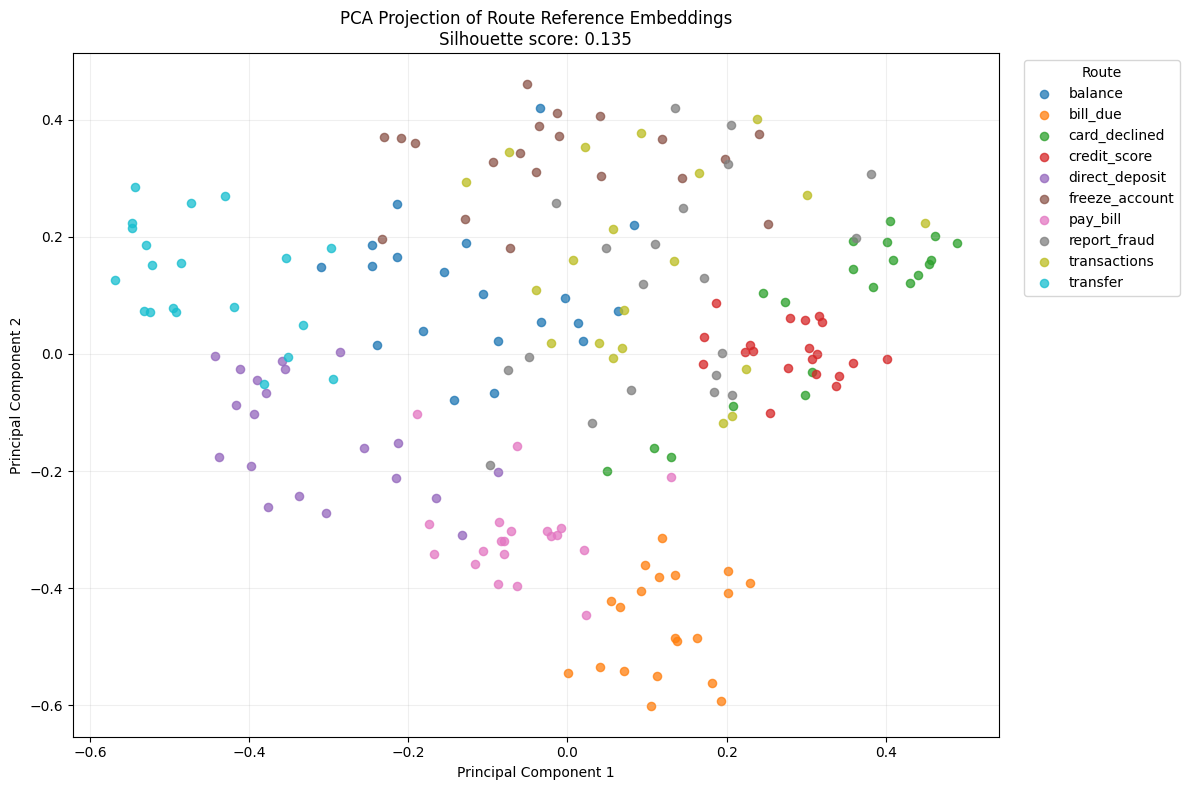

In [86]:
fig, ax, _ = plot_route_pca(low_quality_references, vectorizer=vectorizer)

### Visualizing high quality routes

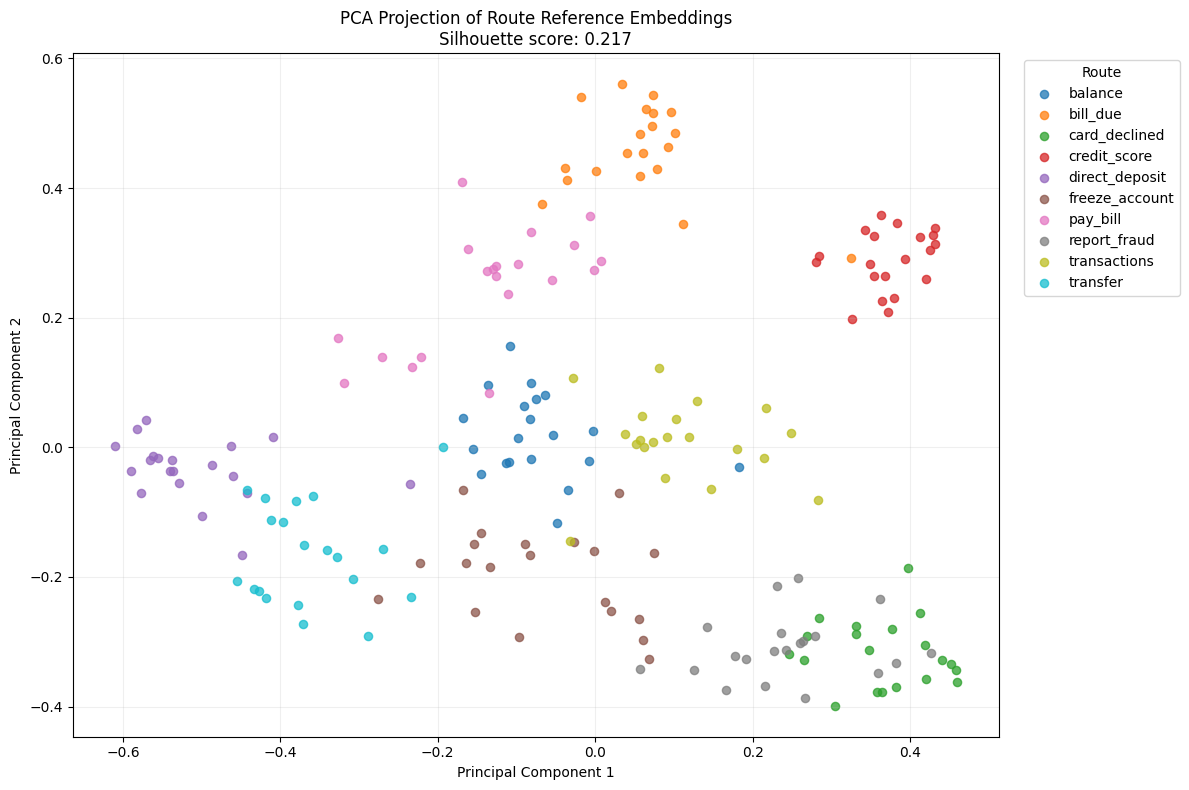

In [87]:
fig, ax, _ = plot_route_pca(high_quality_references, vectorizer=vectorizer)

The high-quality routes have a higher silhouette score, indicating that the route references form tighter and more distinct semantic neighbourhoods. The PCA plot supports this visually too. 

The semantic router would likely perform better when built with these high-quality routes.

### Measuring the quality of your route references

We use this metric called **purity** (see it in action [here](https://pubs.aip.org/aip/acp/article-abstract/2431/1/080013/2906121/K-nearest-neighbor-classifier-optimization-using)) to measure the quality of our route references. For each reference, we find its `k` nearest neighbours in embedding space and check how many belong to the same route. If most neighbours have the same label, that point is pure. Conversely, if most neighbours come from other routes, it is likely that the point lies in an overlapping region, so the purity is low.

Following this definition, the overall purity is the average purity score of all the references within the router. A higher purity would suggest a better route separation, whereas a low purity indicates more overlap between routes.

NOTE: we are using kNN here as our nearest-neighbour algorithm for simplicity, but RedisVL's SemanticRouter uses HNSW (Hierarchical Navigable Small World, read more [here](https://redis.io/blog/how-hnsw-algorithms-can-improve-search/)), which is an approximate nearest-neighbour algorithm. When tuned well, HNSW performs similarly to kNN, but significantly faster.

In [88]:
from sklearn.neighbors import NearestNeighbors

def compute_knn_purity(route_references, vectorizer=vectorizer, k=5):
    """
    Compute exact k-NN purity for route references using scikit-learn.

    For each reference, this function finds its `k` nearest neighbors and
    measures the fraction that belong to the same route. The final score is
    the average of those per-reference purity values.
    """
    texts = []
    labels = []

    # Flatten the route dictionary into parallel text and label lists.
    for route_name, references in route_references.items():
        for reference in references:
            texts.append(reference)
            labels.append(route_name)

    if len(texts) < 2:
        raise ValueError("At least two references are required to compute k-NN purity.")

    if len(set(labels)) < 2:
        raise ValueError("At least two routes are required to compute k-NN purity.")

    # Generate embeddings in the original semantic space.
    embeddings = np.array(vectorizer.embed_many(texts), dtype=np.float32)

    k = min(k, len(texts) - 1)
    if k < 1:
        raise ValueError("`k` must be at least 1 after accounting for dataset size.")

    # Ask for k + 1 neighbors because the closest point is the point itself.
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    nn.fit(embeddings)
    _, indices = nn.kneighbors(embeddings)

    purity_values = []

    for i, neighbors in enumerate(indices):
        source_label = labels[i]

        # Remove the self-match at position 0.
        neighbor_indices = neighbors[1:]

        # Compute purity as the fraction of local neighbors that stay within the
        # same route cluster.
        same_route_count = sum(labels[j] == source_label for j in neighbor_indices)
        purity = same_route_count / k
        purity_values.append(purity)

    # Average across all references to get one route-set-level purity score.
    return float(np.mean(purity_values))


In [89]:
low_quality_knn_purity = compute_knn_purity(low_quality_references, vectorizer=vectorizer, k=5)
high_quality_knn_purity = compute_knn_purity(high_quality_references, vectorizer=vectorizer, k=5)

print(f"kNN purity on low-quality references: {low_quality_knn_purity:.3f}")
print(f"kNN purity on high-quality references: {high_quality_knn_purity:.3f}")

kNN purity on low-quality references: 0.876
kNN purity on high-quality references: 0.953


The high-quality references have a higher purity value, suggesting better separation between routes.

## Conclusion

In this notebook, we explored how to visualize the routes in your semantic router and introduced silhouette score and purity as metrics to assess whether your route references are well-defined. These tools can be used as a gauge to tell whether your route references are of good quality, or whether they require further refinement (refer [here](02_advanced_semantic_routing.ipynb) for some strategies to do so).

When building your semantic router, a useful rule of thumb is that the quality of references usually matters more than quantity. In practice, a small but carefully curated set of references will often perform better than a larger but messier set.

## Cleanup

In [63]:
client.flushall()

True